In [5]:
from datetime import datetime, timedelta

# Define the start and end datetime strings
start_datetime_str = "2024-05-27 09:55:28" 
end_datetime_str = "2024-05-28 20:55:37" 

# Convert the datetime strings to datetime objects
start_datetime = datetime.strptime(start_datetime_str, "%Y-%m-%d %H:%M:%S")
end_datetime = datetime.strptime(end_datetime_str, "%Y-%m-%d %H:%M:%S")
 
# Calculate the difference between the end and start times
time_difference = end_datetime - start_datetime

# Calculate the total number of hours
total_hours = time_difference.total_seconds() / 3600

# Counting hours day to day 
current_datetime = start_datetime
hour_counts = {}

while current_datetime < end_datetime:
    day_key = current_datetime.strftime("%Y-%m-%d")
    if day_key not in hour_counts:
        hour_counts[day_key] = 0
    hour_counts[day_key] += 1
    current_datetime += timedelta(hours=1)

total_hours, hour_counts


(35.0025, {'2024-05-27': 15, '2024-05-28': 21})

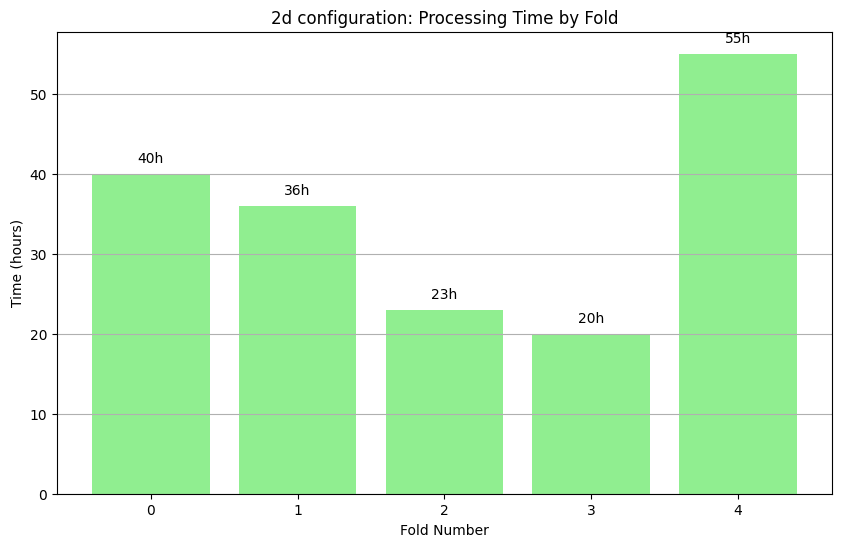

In [4]:
# Step 2: Parse the data
folds = [fold['Fold'] for fold in data['nnUNetPlans_2d']]
times = [int(fold['Times'].rstrip(' h')) for fold in data['nnUNetPlans_2d']]  # Extracting and converting hours to integers

# Step 3: Create the bar chart for times
plt.figure(figsize=(10, 6))
bars = plt.bar(folds, times, color='lightgreen')

# Annotating each bar with the time
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f'{yval}h', ha='center', va='bottom')

plt.title('2d configuration: Processing Time by Fold')
plt.xlabel('Fold Number')
plt.ylabel('Time (hours)')
plt.xticks(folds)  # Ensure x-axis ticks match fold numbers
plt.grid(axis='y')
plt.show()

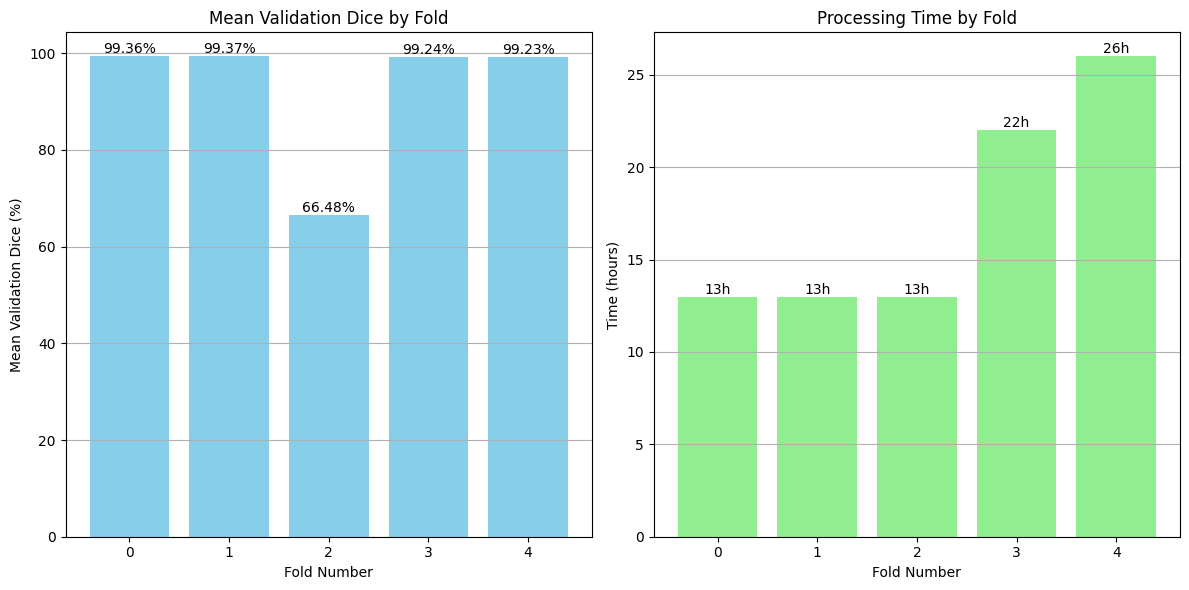

In [9]:
data_3d_lowres = {
    "3d_lowres": [
        {
            "Fold": 0,
            "Times": "13 h",
            "Mean Validation Dice": "99.36%"
        },
        {
            "Fold": 1,
            "Times": "13 h",
            "Mean Validation Dice": "99.37%"
        },
        {
            "Fold": 2,
            "Times": "13 h",
            "Mean Validation Dice": "66.48%"
        },
        {
            "Fold": 3,
            "Times": "22 h",
            "Mean Validation Dice": "99.24%"
        },
        {
            "Fold": 4,
            "Times": "26 h",
            "Mean Validation Dice": "99.23%"
        }
    ]
}


# Now, let's plot the Mean Validation Dice and Processing Time charts

import matplotlib.pyplot as plt

# Extracting data for plotting
folds = [fold['Fold'] for fold in data_3d_lowres['3d_lowres']]
validation_dice = [float(fold['Mean Validation Dice'].rstrip('%')) for fold in data_3d_lowres['3d_lowres']]
times = [int(fold['Times'].rstrip(' h')) for fold in data_3d_lowres['3d_lowres']]

plt.figure(figsize=(12, 6))

# Plotting Mean Validation Dice with adjusted text placement and optional ylim adjustment
plt.subplot(1, 2, 1)
bars = plt.bar(folds, validation_dice, color='skyblue')
plt.title('Mean Validation Dice by Fold')
plt.xlabel('Fold Number')
plt.ylabel('Mean Validation Dice (%)')
plt.xticks(folds)
plt.grid(axis='y')
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2.0, height, f'{height}%', ha='center', va='bottom')  # Adjust va='bottom' offset if needed

# Plotting Processing Time with adjusted text placement and optional ylim adjustment
plt.subplot(1, 2, 2)
bars = plt.bar(folds, times, color='lightgreen')
plt.title('Processing Time by Fold')
plt.xlabel('Fold Number')
plt.ylabel('Time (hours)')
plt.xticks(folds)
plt.grid(axis='y')
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2.0, height, f'{height}h', ha='center', va='bottom')  # Adjust va='bottom' offset if needed

plt.tight_layout()
plt.show()


In [4]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

# Load the NIfTI file
nifti_path = '/work/shared/ngmm/scripts/Taiabur/ngmm-nnunet/dataset/nnUNet_raw_data/Dataset002_HCFC1/labelsTr/NG4111_RCL5.nii.gz'
org_nifti_path = '/work/shared/ngmm/scripts/Taiabur/ngmm-nnunet/dataset/nnUNet_results/Dataset002_HCFC1/nnUNetTrainer__nnUNetPlans__3d_fullres/fold_0/validation/NG4111_RCL5.nii.gz'
img = nib.load(nifti_path)
data = img.get_fdata()

org_img = nib.load(org_nifti_path).get_fdata()

data = org_img * data
# Adjusted function to display a slice and its histogram
def display_slice_and_histogram(slice_no):
    # Setup the figure and axes for a side-by-side plot: slice and histogram
    fig, axes = plt.subplots(2, 2, figsize=(16, 8))
    
    # Display the slice
    ax = axes[0,0]
    ax.imshow(data[:, :, slice_no])
    ax.axis('off')  # Hide axes ticks
    ax.set_title(f'Slice {slice_no}')
    
    # Display the histogram
    ax = axes[0,1]
    slice_data = data[:, :, slice_no].ravel()
    ax.hist(slice_data, bins=50, color='c', alpha=0.75)
    ax.set_title('Pixel Intensity Distribution')
    ax.grid(True)

    ax = axes[1,0]
    ax.imshow(data[:, slice_no,: ].T)
    ax.axis('off')  # Hide axes ticks
    ax.set_title(f'Slice {slice_no}')

    ax = axes[1,1]
    ax.imshow(data[slice_no, :,: ])
    ax.axis('off')  # Hide axes ticks
    ax.set_title(f'Slice {slice_no}')
    
    plt.tight_layout()
    plt.show()

# Interactive widget for slice selection
slice_slider = widgets.IntSlider(
    min=0, 
    max=data.shape[2] - 1, 
    step=1, 
    value=data.shape[2] // 2, 
    description='Slice'
)

widgets.interactive(display_slice_and_histogram, slice_no=slice_slider)


interactive(children=(IntSlider(value=227, description='Slice', max=454), Output()), _dom_classes=('widget-int…

In [6]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

# Load the NIfTI file
nifti_path = '/work/shared/ngmm/scripts/Taiabur/ngmm-nnunet/dataset/nnUNet_raw_data/Dataset002_HCFC1/labelsTr/NG4111_RCL5.nii.gz'
gt_nifti_path = '/work/shared/ngmm/scripts/Taiabur/ngmm-nnunet/dataset/nnUNet_results/Dataset002_HCFC1/nnUNetTrainer__nnUNetPlans__3d_fullres/fold_0/validation/NG4111_RCL5.nii.gz'
img = nib.load(nifti_path)
data = img.get_fdata()

gt_data = nib.load(gt_nifti_path).get_fdata()

nww_data = gt_data * data
# Adjusted function to display a slice and its histogram
def display_slice_and_histogram(slice_no):
    # Setup the figure and axes for a side-by-side plot: slice and histogram
    fig, axes = plt.subplots(2,4, figsize=(16, 8))
    
    # Display the slice
    ax = axes[0,0]
    ax.imshow(data[:, :, slice_no])
    ax.axis('off')  # Hide axes ticks
    ax.set_title(f'Slice {slice_no}')
    
    # Display the histogram
    ax = axes[0,1]
    slice_data = data[:, :, slice_no].ravel()
    ax.hist(slice_data, bins=50, color='c', alpha=0.75)
    ax.set_title('Img: Pixel Intensity Distribution')
    ax.grid(True)

    ax = axes[1,0]
    ax.imshow(data[:, slice_no,: ].T)
    ax.axis('off')  # Hide axes ticks
    ax.set_title(f'Img: Slice {slice_no}')

    ax = axes[1,1]
    ax.imshow(data[slice_no, :,: ])
    ax.axis('off')  # Hide axes ticks
    ax.set_title(f'Img: Slice {slice_no}')

    # gt 
    # Display the slice
    ax = axes[0,2]
    ax.imshow(gt_data[:, :, slice_no])
    ax.axis('off')  # Hide axes ticks
    ax.set_title(f'GT: Slice {slice_no}')
    
    # Display the histogram
    ax = axes[0,3]
    slice_data = gt_data[:, :, slice_no].ravel()
    ax.hist(slice_data, bins=50, color='c', alpha=0.75)
    ax.set_title('Img: Pixel Intensity Distribution')
    ax.grid(True)

    ax = axes[1,2]
    ax.imshow(gt_data[:, slice_no,: ].T)
    ax.axis('off')  # Hide axes ticks
    ax.set_title(f'GT: Slice {slice_no}')

    ax = axes[1,3]
    ax.imshow(gt_data[slice_no, :,: ])
    ax.axis('off')  # Hide axes ticks
    ax.set_title(f'GT: Slice {slice_no}')
    
    plt.tight_layout()
    plt.show()

# Interactive widget for slice selection
slice_slider = widgets.IntSlider(
    min=0, 
    max=data.shape[2] - 1, 
    step=1, 
    value=data.shape[2] // 2, 
    description='Slice'
)

widgets.interactive(display_slice_and_histogram, slice_no=slice_slider)


interactive(children=(IntSlider(value=227, description='Slice', max=454), Output()), _dom_classes=('widget-int…

In [10]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

# Load the NIfTI file
nifti_path = '/work/shared/ngmm/scripts/Taiabur/ngmm-nnunet/dataset/nnUNet_raw_data/Dataset002_HCFC1/imagesTr/NG4110_RCL5_0000.nii.gz'
gt_nifti_path = '/work/shared/ngmm/scripts/Taiabur/ngmm-nnunet/dataset/nnUNet_results/Dataset002_HCFC1/nnUNetTrainer__nnUNetPlans__3d_lowres/fold_4/validation/NG4110_RCL5.nii.gz'
img = nib.load(nifti_path)
data = img.get_fdata()

gt_data = nib.load(gt_nifti_path).get_fdata()

nww_data = gt_data * data
# Adjusted function to display a slice and its histogram
def display_slice_and_histogram(slice_no):
    # Setup the figure and axes for a side-by-side plot: slice and histogram
    fig, axes = plt.subplots(2,4, figsize=(16, 8))
    
    # Display the slice
    ax = axes[0,0]
    ax.imshow(data[:, :, slice_no])
    ax.axis('off')  # Hide axes ticks
    ax.set_title(f'Slice {slice_no}')
    
    

    ax = axes[0,1]
    ax.imshow(data[:, slice_no,: ].T)
    ax.axis('off')  # Hide axes ticks
    ax.set_title(f'Img: Slice {slice_no}')

    ax = axes[0,2]
    ax.imshow(data[slice_no, :,: ])
    ax.axis('off')  # Hide axes ticks
    ax.set_title(f'Img: Slice {slice_no}')

    # Display the histogram
    ax = axes[0,3]
    slice_data = data[:, :, slice_no].ravel()
    ax.hist(slice_data, bins=50, color='c', alpha=0.75)
    ax.set_title('Img: Pixel Intensity Distribution')
    ax.grid(True)

    # gt 
    # Display the slice
    ax = axes[1,0]
    ax.imshow(gt_data[:, :, slice_no])
    ax.axis('off')  # Hide axes ticks
    ax.set_title(f'GT: Slice {slice_no}')

    ax = axes[1,1]
    ax.imshow(gt_data[:, slice_no,: ].T)
    ax.axis('off')  # Hide axes ticks
    ax.set_title(f'GT: Slice {slice_no}')

    ax = axes[1,2]
    ax.imshow(gt_data[slice_no, :,: ])
    ax.axis('off')  # Hide axes ticks
    ax.set_title(f'GT: Slice {slice_no}')

    # Display the histogram
    ax = axes[1,3]
    slice_data = gt_data[:, :, slice_no].ravel()
    ax.hist(slice_data, bins=50, color='c', alpha=0.75)
    ax.set_title('Img: Pixel Intensity Distribution')
    ax.grid(True)

    fig.suptitle('3D Slice Viewer', fontsize=16)

    plt.tight_layout()
    plt.show()
    

# Interactive widget for slice selection
slice_slider = widgets.IntSlider(
    min=0, 
    max=data.shape[2] - 1, 
    step=1, 
    value=data.shape[2] // 2, 
    description='Slice'
)

widgets.interactive(display_slice_and_histogram, slice_no=slice_slider)


interactive(children=(IntSlider(value=228, description='Slice', max=456), Output()), _dom_classes=('widget-int…